In [6]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from lensim.host import Host
from lensim.simulator import Simulator
from lensim.utils import jain, tail, microsec, kB, Gbps

/home/smrn/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 1. Prepare trainning dataset.

In [8]:
packet_size = 5e6
n_hosts = 100
n_loops = 500000
cable_delay = 50
target_delay = 400

In [9]:
%%time
net = Simulator(logger=True)
for _ in range(n_hosts):
    net.add(Host((0, n_loops), cable_delay, target_delay, cwnd=1.5))
lenq, t_acks, cwnds, rtts, throughputs = net.simulate(n_loops, settling=n_loops//2)
all_rtts = np.concatenate(rtts)
tail99 = tail(all_rtts, 0.99)
print("=== Simulation results ===")
print(f'Throughput: {50*throughputs.sum():.1f} Gbps')
print(f"Mean RTT: {np.mean(all_rtts)*1.6e-07/microsec:.1f} us")
print(f"99th-p RTT: {tail99*1.6e-07/microsec:.1f} us")
print(f"Jain's fairness: J={jain(throughputs):.3f}")

Log saved to network_log1
[0]
=== Simulation results ===
Throughput: 50.0 Gbps
Mean RTT: 28.7 us
99th-p RTT: 35.1 us
Jain's fairness: J=1.000
CPU times: user 13.9 s, sys: 216 ms, total: 14.1 s
Wall time: 14.1 s


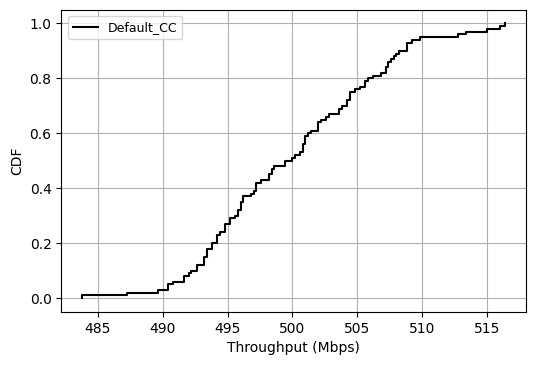

In [10]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1,1, figsize=(6, 4), dpi=100)
ax.ecdf(50e3*throughputs, c='k', label='Default_CC')
ax.grid()
ax.set_ylim([-0.05,1.05])
ax.set_xlabel('Throughput (Mbps)')
ax.set_ylabel('CDF')
ax.legend(loc = 'upper left', fontsize=9)

### 2. Train model

In [1]:
from sklearn.model_selection import train_test_split 
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from regrsim.simulator import NewSimulator
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import joblib

In [2]:
lines = []
with open('./log/network_log1', 'r') as file:
    lines = file.readlines()
    
X = [s.split(',')[1:11] for s in lines][1:] # cwnd_prev,can_decrease,target_delay,total_acked,pacing_delay,first,rtt,prev_rtt,delay,now
y = [s.split(',')[11] for s in lines][1:] # cwnd
for fs in X: del fs[5]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LinearSVR(verbose=True)

params = {
    'C': [1],
    'epsilon': [0.1],
    'max_iter': [1000],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring='r2',          #R^2
    cv=3,
    verbose=4,
    n_jobs=-1,
    refit='r2'
)

# Обучение модели
grid_search.fit(X_train, y_train)

Fitting 2 folds for each of 1 candidates, totalling 2 fits
.................................................................................................................................................................................................
optimization finished, #iter = 1000

Using -s 11 may be faster

Objective value = -2525.278233
nSV = 57824
..

/home/smrn/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


.....
optimization finished, #iter = 1000

Using -s 11 may be faster

Objective value = -2524.762300
nSV = 58210


/home/smrn/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[LibLinear]....................................................................................................
optimization finished, #iter = 1000

Using -s 11 may be faster

Objective value = -5049.278186
nSV = 116088


/home/smrn/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=2, estimator=LinearSVR(verbose=True), n_jobs=-1,
             param_grid={'C': [1], 'epsilon': [0.1], 'max_iter': [1000]},
             refit='r2', scoring='r2', verbose=4)

In [4]:
print("Best params: ", grid_search.best_params_)
print("MSE", -grid_search.best_score_)

best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)
print("MSE with y_test:", root_mean_squared_error(y_test, pred))
print("R2 with y_test: ", r2_score(y_test, pred))


Best params:  {'C': 1, 'epsilon': 0.1, 'max_iter': 1000}
MSE -0.8738282818218706
MSE with y_test: 0.09304901104272584
R2 with y_test:  0.8757031719633461


In [11]:


%%time

joblib.dump(best_model, 'model.pkl')

new_net = NewSimulator(logger=True)
for _ in range(n_hosts):
    new_net.add(Host((0, n_loops), cable_delay, target_delay, cwnd=1.5))
lenq_, t_acks_, cwnds_, rtts_, throughputs_ = new_net.simulate(n_loops, settling=n_loops//2)
all_rtts_ = np.concatenate(rtts_)
tail99 = tail(all_rtts_, 0.99)
print("=== Simulation results ===")
print(f'Throughput: {50*throughputs_.sum():.1f} Gbps')
print(f"Mean RTT: {np.mean(all_rtts_)*1.6e-07/microsec:.1f} us")
print(f"99th-p RTT: {tail99*1.6e-07/microsec:.1f} us")
print(f"Jain's fairness: J={jain(throughputs_):.3f}")



Log saved to network_log2
[0]
=== Simulation results ===
Throughput: 50.0 Gbps
Mean RTT: 28.7 us
99th-p RTT: 35.0 us
Jain's fairness: J=1.000
CPU times: user 13.9 s, sys: 228 ms, total: 14.2 s
Wall time: 14.2 s
[LibLinear][CV 1/2] END ...C=1, epsilon=0.1, max_iter=1000;, score=0.875 total time=  24.6s
[LibLinear][CV 2/2] END ...C=1, epsilon=0.1, max_iter=1000;, score=0.873 total time=  25.2s


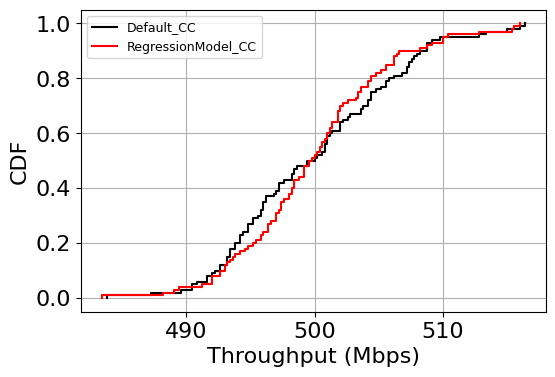

In [12]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1,1, figsize=(6, 4), dpi=100)
ax.ecdf(50e3*throughputs, c='k', label='Default_CC')
ax.ecdf(50e3*throughputs_, c='r', label='RegressionModel_CC')
ax.grid()
ax.set_ylim([-0.05,1.05])
ax.set_xlabel('Throughput (Mbps)')
ax.set_ylabel('CDF')
ax.legend(loc = 'upper left', fontsize=9)